# QSDTS: keyless quantum-secure file transfer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gowtham472/qsdts/blob/main/notebooks/qsdts_demo.ipynb)

**Team DoodleByte** · Q-Hack India 2026 · Quantum Security & Cryptography

QSDTS sends a file across a network where **the message itself is the quantum state**
(DL04 Quantum Secure Direct Communication), so no key is ever generated, stored or
transmitted. Every link checks for an eavesdropper *before* the message is encoded,
and the network routes around any link that fails.

Everything below runs on Qiskit Aer in about two minutes. Use **Runtime > Run all**.

Source: https://github.com/gowtham472/qsdts

## Setup

In [1]:
try:
    import qsdts
except ImportError:
    %pip install -q "qsdts @ git+https://github.com/gowtham472/qsdts"
    import qsdts

import numpy as np
import matplotlib.pyplot as plt
from qsdts import dl04, bb84
from qsdts.channel import Link, QuantumBackend
from qsdts.coding import encode_frame, decode_frame
from qsdts.network import demo_topology
print("qsdts", qsdts.__version__)

qsdts 0.1.0


## 1. One DL04 session on a clean fibre

Bob prepares random qubits and sends them. Alice measures a random subset to check
for an eavesdropper. Only if the error rate (QBER) is low does she encode the message
on the remaining qubits (I for 0, iY for 1) and send them back. Bob decodes in his own
bases.

In [2]:
be, rng = QuantumBackend(seed=1), np.random.default_rng(1)
r = dl04.send(encode_frame(b"no key was ever created"), Link("Alice", "Bob", depol=0.0), be, rng)
data, ok = decode_frame(r.payload)
print(f"forward check QBER: {100*r.qber_forward:.1f}%   aborted: {r.aborted}")
print(f"Bob decoded: {data.rstrip(bytes(1))!r}   integrity ok: {ok}")
print(f"qubits prepared: {r.qubits_prepared}")

forward check QBER: 0.0%   aborted: False
Bob decoded: b'no key was ever created'   integrity ok: True
qubits prepared: 664


## 2. An eavesdropper, and the 25% signature

Eve intercepts every qubit and measures it in a random basis. She picks the wrong basis
half the time, and then the bit reads wrong half the time: 0.5 x 0.5 = **25%**.
Pooled over many sessions, the simulation must reproduce that.

In [3]:
be, rng = QuantumBackend(seed=21), np.random.default_rng(21)
errors = sifted = 0
for _ in range(100):
    r = dl04.send(np.zeros(448, np.uint8), Link("A", "B", depol=0.0, eve=1.0), be, rng,
                  proceed_below=1.01)
    errors += round(r.qber_forward * r.sifted_forward)
    sifted += r.sifted_forward
se = (0.25 * 0.75 / sifted) ** 0.5
q = errors / sifted
print(f"measured QBER: {100*q:.2f}%  over {sifted} check bits")
print(f"theory 25%   standard error {100*se:.2f}%   z = {(q - 0.25)/se:+.2f}  (|z| < 3 is consistent)")

measured QBER: 25.18%  over 8289 check bits
theory 25%   standard error 0.48%   z = +0.37  (|z| < 3 is consistent)


## 3. The invariant: abort *before* encoding

If the check fails, the message must never touch the channel. Here every message bit
is a 1, so encoding would need Y gates. We count them.

In [4]:
from qiskit import QuantumCircuit
calls = {"y": 0}
_orig = QuantumCircuit.y
def counting_y(self, *a, **k):
    calls["y"] += 1
    return _orig(self, *a, **k)
QuantumCircuit.y = counting_y
try:
    r = dl04.send(np.ones(448, np.uint8), Link("A", "B", depol=0.0, eve=1.0),
                  QuantumBackend(seed=3), np.random.default_rng(3))
finally:
    QuantumCircuit.y = _orig
print(f"aborted: {r.aborted}   QBER: {100*r.qber_forward:.1f}%")
print(f"encoding gates created: {calls['y']}   message bits on channel: {r.message_bits_on_channel}")

aborted: True   QBER: 17.6%
encoding gates created: 0   message bits on channel: 0


## 4. A file across the network, attacked mid-transfer

Five nodes. Each hop is its own DL04 session through a trusted relay. At frame 5 an
eavesdropper taps the R1-Bob fibre. Watch the network detect it and reroute.

In [5]:
data = (b"QSDTS demo: this file crosses a quantum network while an eavesdropper "
        b"taps a link mid-transfer. The network detects it and routes around. ") * 3

def show(e):
    if e.kind in ("abort", "reroute", "fail"):
        q = "" if e.qber is None else f"QBER {100*e.qber:.1f}%  "
        print(f"frame {e.frame+1:2d}  {e.kind.upper():8s} {e.link:10s} {q}{e.detail}")

rep = demo_topology().transfer(data, "Alice", "Bob", QuantumBackend(seed=5),
                               np.random.default_rng(5), attacks={4: ("R1", "Bob", 1.0)},
                               on_event=show)
print()
for p in rep.paths:
    print("path used:", " > ".join(p))
print("SHA-256 sent    ", rep.sha256_sent)
print("SHA-256 received", rep.sha256_received)
print("verified:", rep.verified, "  message bits exposed on aborted sessions:",
      rep.message_bits_on_aborted_sessions)

frame  5  ABORT    R1-Bob     QBER 24.4%  ABORT: message never encoded
frame  5  REROUTE  R1-Bob     QBER 24.4%  R1 routes around R1-Bob via R1-R3-Bob



path used: Alice > R1 > Bob
path used: Alice > R1 > R3 > Bob
SHA-256 sent     d663937a8cd13d42b013924c1972e40f070cbbefb7ea0b171ce2e08478ae1b94
SHA-256 received d663937a8cd13d42b013924c1972e40f070cbbefb7ea0b171ce2e08478ae1b94
verified: True   message bits exposed on aborted sessions: 0


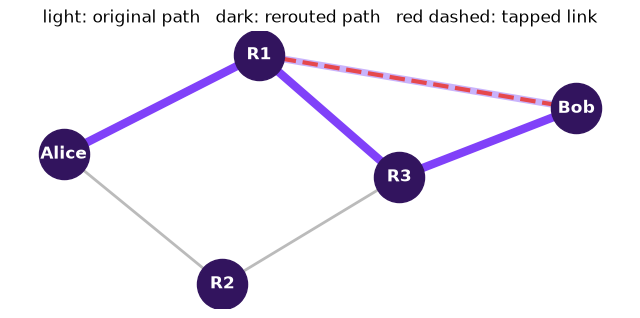

In [6]:
import networkx as nx
net = demo_topology()
pos = {"Alice": (0, .5), "R1": (1.6, 1.15), "R2": (1.3, -.35), "R3": (2.75, .35), "Bob": (4.2, .8)}
fig, ax = plt.subplots(figsize=(8, 3.6))
nx.draw_networkx_edges(net.g, pos, ax=ax, edge_color="#bbbbbb", width=2)
for path, col, w in ((rep.paths[0], "#c9b3fb", 5), (rep.paths[-1], "#8041F9", 6)):
    nx.draw_networkx_edges(net.g, pos, edgelist=list(zip(path, path[1:])), ax=ax,
                           edge_color=col, width=w, arrows=True, arrowsize=18)
nx.draw_networkx_edges(net.g, pos, edgelist=[("R1", "Bob")], ax=ax, edge_color="#E5484D",
                       width=3, style="dashed")
nx.draw_networkx_nodes(net.g, pos, ax=ax, node_color="#32145E", node_size=1300)
nx.draw_networkx_labels(net.g, pos, ax=ax, font_color="white", font_weight="bold")
ax.set_title("light: original path   dark: rerouted path   red dashed: tapped link")
ax.axis("off");

## 5. How strong must an attack be to be caught?

Sweep the fraction of qubits Eve intercepts, with 1% realistic fibre noise. A block is
stopped when its check exceeds 8% QBER.

attack   0%   mean QBER   0.2%   blocks stopped   0.0%


attack  20%   mean QBER   6.1%   blocks stopped  33.3%


attack  40%   mean QBER  11.0%   blocks stopped  75.0%


attack  60%   mean QBER  15.4%   blocks stopped 100.0%


attack 100%   mean QBER  26.7%   blocks stopped 100.0%


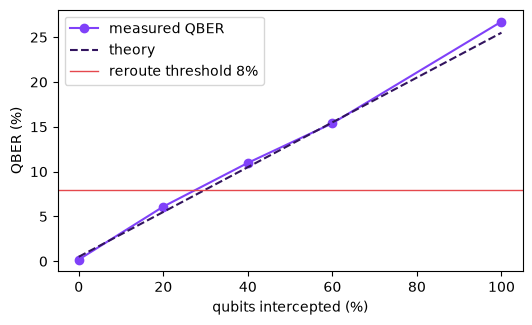

In [7]:
fracs = [0.0, 0.2, 0.4, 0.6, 1.0]
means, caught = [], []
for i, f in enumerate(fracs):
    be, rng = QuantumBackend(seed=200+i), np.random.default_rng(200+i)
    qs = [dl04.send(encode_frame(b"y"*28), Link("A","B", depol=0.01, eve=f), be, rng)
          for _ in range(12)]
    means.append(100*np.mean([r.qber_forward for r in qs]))
    caught.append(100*np.mean([r.aborted for r in qs]))
    print(f"attack {int(100*f):3d}%   mean QBER {means[-1]:5.1f}%   blocks stopped {caught[-1]:5.1f}%")
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot([100*f for f in fracs], means, "o-", color="#8041F9", label="measured QBER")
ax.plot([0, 100], [0.5, 25.5], "--", color="#32145E", label="theory")
ax.axhline(8, color="#E5484D", lw=1, label="reroute threshold 8%")
ax.set_xlabel("qubits intercepted (%)"); ax.set_ylabel("QBER (%)"); ax.legend();

**Honest limit:** attacks on half the qubits or more are stopped on every block, but a
weak attacker (about 20%) hides inside fibre noise within a single block. Detecting it
across many blocks is our Round 2 research question.

## 6. DL04 vs BB84 on the same channel

In [8]:
be, rng = QuantumBackend(seed=11), np.random.default_rng(11)
d = dl04.send(encode_frame(b"x"*28), Link("A","B", depol=0.01), be, rng)
b = bb84.exchange(4000, Link("A","B", depol=0.01), be, rng)
print(f"DL04: {448/d.qubits_prepared:.3f} message bits per qubit prepared, "
      f"{448/d.channel_uses:.3f} per fibre transmission")
print(f"BB84: {len(b.key_alice)/b.qubits_prepared:.3f} key bits per qubit (one per transmission)")
print("DL04 wins per qubit prepared but sends each qubit twice; the real difference is that no key exists.")

DL04: 0.675 message bits per qubit prepared, 0.386 per fibre transmission
BB84: 0.363 key bits per qubit (one per transmission)
DL04 wins per qubit prepared but sends each qubit twice; the real difference is that no key exists.
